# Example: Measuring T1

T1 is an experiment that measures the relaxation time of a qubit.

Information stored in a qubit decays exponentially. The time constant of the longitudinal decay is called the relaxation time $T_1$.

The experiment measures $T_1$ by preparing selected qubits in the  excited state by applying an X gate,
waiting some time, and measuring the qubit.

The waiting time is swept to reveal the exponential decay of the excited state probability.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from exa.common.control.sweep.sweep import Sweep

from iqm.pulla.pulla import Pulla
from iqm.pulse import Circuit
from iqm.pulse import CircuitOperation as Op
from iqm.pulse.playlist.visualisation.base import inspect_playlist
from iqm.qiskit_iqm import IQMProvider

In [ ]:
iqm_server_url = os.environ['PULLA_IQM_SERVER_URL']  # or set the URL directly here
os.environ["IQM_TOKEN"] = os.environ.get("IQM_TOKEN")  # or set the token directly here

p = Pulla(iqm_server_url)
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()
compiler = p.get_standard_compiler()

## Preparing the circuit

We need to select the physical qubits to work on. These are available on the QPU:

In [30]:
qubits = compiler.chip_topology.qubits_sorted
qubits

('QB1', 'QB2', 'QB3', 'QB4', 'QB5')

Out of these, we select a few:

In [31]:
qubits = qubits[0:2]

Now we create all the circuits. In each circuit, we do a PRX($\pi$), or $X$, then a delay operation, then measure all qubits.
Instead of creating a circuit for each delay time (old method), we now create a parametric circuit by defining a circuit generating function with `delay` being the main input variable.

In [ ]:
def _t1_circuit(delay: float = 0.0) -> list[Circuit]:
    instructions = []
    for qubit in qubits:
        instructions += [
            Op("prx", (qubit,), args={"angle": np.pi, "phase": 0.0}),
            Op("delay", (qubit,), args={"duration": delay}),
        ]
    instructions.append(Op("measure", qubits, args={"key": "M"}))

    return [Circuit("T1", tuple(instructions))]

settings = compiler.get_settings(circuits=_t1_circuit)

In [33]:
delay_sweep = Sweep(
    parameter=settings.stages.circuit_generation.circuit.delay.parameter,
    data=np.linspace(0.0, 300e-6, 51),  # In seconds
)

settings.controllers.options.playlist_repeats = 500
# Average over shots. In normal circuit execution, this would be equivalent to averaging over shots
settings.controllers.options.averaging_bins = 1
# We can also achieve the same with
settings.set_shots(500, averaging_bins=1)

job_definition, context = compiler.compile(
    circuits=_t1_circuit,
    components=["QB1", "QB2"],
    settings=settings,
    sweeps=[delay_sweep],
)

Then compile the circuits. We tweak the settings so that the shots are averaged by the server, so that we don't need to.
The results therefore return as sampled probabilities.

In [34]:
shots = settings.controllers.options.playlist_repeats
time_axis = np.asarray(delay_sweep.data)

In [ ]:
job = p.submit_playlist(job_definition, context=context)
job.wait_for_completion()

We can also visualise the final playlist. We should see that each circuit is different and the waits at the end are increasing towards the end.

In [ ]:
from IPython.core.display import HTML
HTML(inspect_playlist(job_definition.sweep_definition.playlist, range(5))) # Show first 5 circuits


Extract and plot the results

QB1 T1 =  22.3 µs
QB2 T1 =  30.2 µs


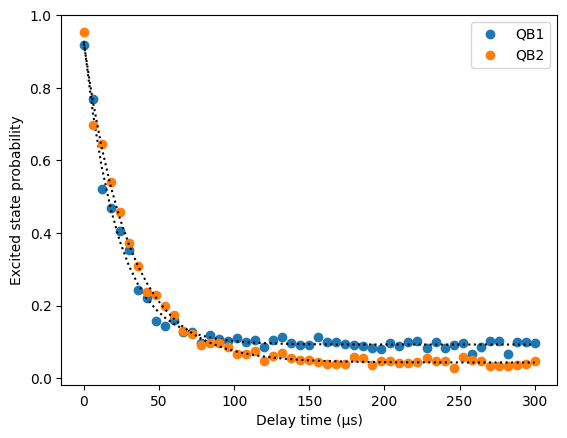

In [36]:
def exp_func(x, a, b, c):
    return a * np.exp(- x / b) + c

plt.figure()
x = time_axis * 1e6

results = job.result().circuit_measurement_results

for i, qubit in enumerate(qubits):
    # results is a list of CircuitMeasurementResults, one per circuit in the sweep
    # Since we set averaging_bins = shots, the results contains averaged probabilities
    y = np.array([res["M"][0][i] for res in results])
    
    popt, _ = curve_fit(exp_func, time_axis, y, p0=[1, 50e-6, 0])  
    print(f"{qubit} T1 = {popt[1]*1e6 : .1f} µs")
    
    plt.plot(x, y, 'o', label=qubit)
    plt.plot(x, exp_func(np.array(time_axis), *popt), 'k:')
    
plt.xlabel("Delay time (µs)")
plt.ylabel("Excited state probability")
plt.legend()
plt.show()
